# RED NEURONAL con Keras y Tensorflow. Ejemplo con dataset IRIS.

1. Cargar librerías. 📚

In [2]:
import tensorflow as tf 
from tensorflow import keras 
import numpy as np 
import matplotlib.pyplot as plt

2. Cargamos el dataset IRIS 🌸

In [3]:
from sklearn.datasets import load_iris
data = load_iris()

3. Separamos las características (X) de las etiquetas (y) ✂️

In [4]:
X = data.data
y = data.target

4. Preparamos los conjuntos de TRAIN y de TEST 🎎

In [5]:
X_train = X[:120] # 120 muestras para entrenamiento
y_train = y[:120] # 120 etiquetas para entrenamiento    
X_test = X[120:]  # 30 muestras para prueba
y_test = y[120:]  # 30 etiquetas para prueba    

5. Construimos la arquitectura de nuestro modelo de RNA ⚙️

In [7]:
model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(4,)),  # Capa de entrada con 4 características (sepal length, sepal width, petal length, petal width)
    keras.layers.Dense(10, activation='relu', input_shape=(4,)),  # Capa oculta con 10 neuronas y función de activación ReLU
    keras.layers.Dense(3, activation='softmax')  # Capa de salida con 3 neuronas (una por clase) y función de activación softmax. Usamos softmax para clasificación multiclase
])

c:\Users\grach\Documents\proyectos\IABD\CEIABD_25_26\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\grach\Documents\proyectos\IABD\CEIABD_25_26\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6.Compilamos 🛠

In [8]:
model.compile(optimizer='adam', # Tomamos el optimizador 'adam' porque es eficiente y ampliamente utilizado
              loss='sparse_categorical_crossentropy', # Usamos sparse_categorical_crossentropy porque las etiquetas son enteros
              metrics=['accuracy']) # Evaluamos la precisión del modelo usando 'accuracy' porque es un problema de clasificación

7. Entrenamiento del modelo 🏋️

In [9]:
model.fit(X_train, y_train, epochs=1000)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4167 - loss: 2.1029
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4167 - loss: 1.9734
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4167 - loss: 1.8581
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4167 - loss: 1.7479 
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4167 - loss: 1.6478
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4167 - loss: 1.5541
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4167 - loss: 1.4706
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4167 - loss: 1.4014
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3917 - loss: 1.3352
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2167 - loss: 1.2798
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0417 - loss: 1.2302
Epoch 12/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy

8. Evaluación 🕵️‍♂️

In [10]:
score = model.evaluate(X_test, y_test, verbose=0)
perdida = score[0] *100
accuracy = score[1] *100
print(f"Pérdida: {perdida:.2f}%")
print(f'Precisión: {accuracy:.2f}%')

Pérdida: 37.06%
Precisión: 80.00%


9. Predicciones 💬

In [11]:
prediccion = model.predict(np.array([[5.1, 3.5, 1.4, 0.2]])) 
print('Predicción (probabilidades por clase):')
c0=(prediccion[0][0]) *100
c1=(prediccion[0][1]) *100
c2=(prediccion[0][2]) *100
print('Clase 0 (setosa): {:.2f}%'.format(c0))
print('Clase 1 (versicolor): {:.2f}%'.format(c1))
print('Clase 2 (virginica): {:.2f}%'.format(c2))   
clase_predicha = np.argmax(prediccion) # Usamos argmax para obtener la clase con la mayor probabilidad, que será la clase predicha por el modelo!
print('Clase predicha:', clase_predicha)  # 0: setosa, 1: versicolor, 2: virginica

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Predicción (probabilidades por clase):
Clase 0 (setosa): 99.98%
Clase 1 (versicolor): 0.02%
Clase 2 (virginica): 0.00%
Clase predicha: 0


### EJERCICIO A REALIZAR. 📝

Usando ahora el dataset de los **Pingüinos", usa un modelo con arquitectura RNA para realizar predicción y compara los resultados con otros modelos vistos previamente.

Diferencias clave con el ejercicio Iris:
Limpieza: Los pingüinos tienen valores vacíos (NaN) que debemos eliminar.

Codificación: Hay columnas de texto (island, sex) que la red neuronal no entiende; debemos convertirlas a números (One-Hot Encoding).

Escalado (Muy importante): En Iris, los valores son pequeños (cm). En Pingüinos, el peso está en gramos (ej. 4500) y el pico en mm (ej. 40). Si no escalamos los datos, la red neuronal se confundirá y tardará mucho en aprender.

Datos de entrenamiento: (266, 7)
Datos de prueba: (67, 7)
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.4812 - loss: 1.0639 - val_accuracy: 0.4074 - val_loss: 1.1563
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5230 - loss: 0.9711 - val_accuracy: 0.4074 - val_loss: 1.0816
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5732 - loss: 0.8926 - val_accuracy: 0.4815 - val_loss: 1.0162
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6569 - loss: 0.8140 - val_accuracy: 0.6296 - val_loss: 0.9253
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8117 - loss: 0.7218 - val_accuracy: 0.8148 - val_loss: 0.8052
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8828 - loss: 0.6353 - val_accuracy: 0.8519 - val_loss: 0.7063
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9038 - loss: 0.5681 - val_accuracy: 0.9259 - val_loss: 0.6274
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18m

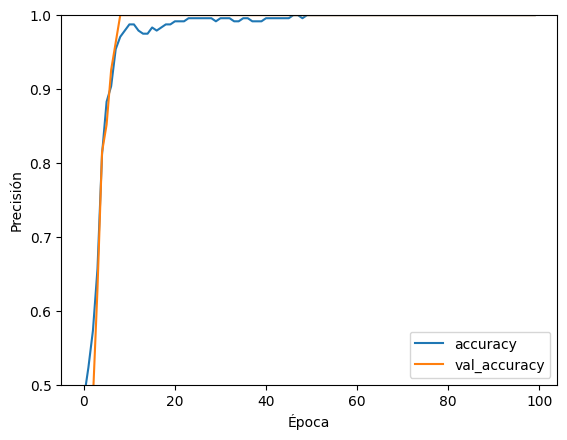

In [12]:
# 1. Cargar librerías 📚
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# 2. Cargar el dataset Pingüinos 🐧
# Asumimos que está en la carpeta 'datasets'  
df = pd.read_csv('datasets/penguins.csv')

# --- PREPROCESAMIENTO (La parte crucial que cambia respecto a Iris) ---

# A. Limpieza: Eliminar filas con datos faltantes (NaN)
df.dropna(inplace=True)

# B. Separar Características (X) y Etiquetas (y)
X_raw = df.drop('species', axis=1) # Todo menos la especie
y_raw = df['species']              # Solo la especie

# C. Codificar la etiqueta (Target) a números (Adelie=0, Chinstrap=1, Gentoo=2)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# D. Codificar variables categóricas de entrada (Island, Sex) a números (One-Hot Encoding)
# Esto convierte 'sex' en dos columnas: 'sex_FEMALE' y 'sex_MALE', etc.
X_encoded = pd.get_dummies(X_raw, columns=['island', 'sex'], drop_first=True)

# E. Escalar los datos numéricos (Normalización)
# Las redes neuronales funcionan MEJOR si todos los datos están entre -1 y 1 aprox.
scaler = StandardScaler()
X = scaler.fit_transform(X_encoded)

# 3. Preparamos los conjuntos de TRAIN y de TEST 🎎
# Usamos train_test_split que mezcla los datos aleatoriamente (importante porque el csv viene ordenado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

# 4. Construimos la arquitectura del modelo RNA ⚙️
model = keras.Sequential([
    # Capa de entrada: input_shape es dinámico según las columnas que generamos
    keras.layers.InputLayer(shape=(X_train.shape[1],)), 
    
    # Capa oculta 1: Aumentamos un poco las neuronas ya que hay más inputs que en Iris
    keras.layers.Dense(16, activation='relu'),
    
    # Capa oculta 2 (Opcional, para darle más potencia)
    keras.layers.Dense(8, activation='relu'),
    
    # Capa de salida: 3 neuronas (porque hay 3 especies de pingüinos) + softmax
    keras.layers.Dense(3, activation='softmax')
])

# 5. Compilamos 🛠
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# 6. Entrenamiento del modelo 🏋️
# Usamos validation_split para ver cómo se comporta con datos que no ve mientras entrena
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

# 7. Evaluación 🕵️‍♂️
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en test: {score[0]*100:.2f}%")
print(f"Precisión en test (Accuracy): {score[1]*100:.2f}%")

# 8. Gráfica de aprendizaje (Opcional pero recomendada)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

Código para Predicción Manual
Vamos a inventar un pingüino que, por sus características (grande y de aleta larga), debería ser un Gentoo.


In [13]:
# 1. Definimos los datos de nuestro "Pingüino Inventado" 🐧
nuevo_pinguino = {
    'island': 'Biscoe',          # Isla
    'bill_length_mm': 50.0,      # Largo del pico
    'bill_depth_mm': 15.0,       # Profundidad del pico
    'flipper_length_mm': 225.0,  # Largo de la aleta (muy larga -> típico de Gentoo)
    'body_mass_g': 5500.0,       # Peso (bastante pesado)
    'sex': 'FEMALE'              # Sexo
}

# Convertimos a DataFrame (como si fuera una mini tabla de 1 fila)
input_df = pd.DataFrame([nuevo_pinguino])

print("--- Datos Originales ---")
print(input_df)

# 2. Preprocesamiento (La parte delicada) ⚙️

# A. Codificar texto a columnas (One-Hot)
input_encoded = pd.get_dummies(input_df, columns=['island', 'sex'], drop_first=True)

# B. ALINEACIÓN DE COLUMNAS (¡Truco vital!)
# El nuevo pingüino puede que no tenga todas las columnas (ej. no es de la isla Torgersen).
# Forzamos a que tenga las mismas columnas que X_encoded (los datos de entrenamiento).
input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# C. Escalar los datos (Usando el MISMO scaler que entrenamos antes)
input_scaled = scaler.transform(input_encoded)

# 3. Predicción 🔮
prediccion = model.predict(input_scaled)

# 4. Interpretar el resultado 🗣️
print("\n--- Resultados de la Red Neuronal ---")
print(f"Probabilidades crudas: {prediccion[0]}")

# Obtenemos el índice de la probabilidad más alta
clase_predicha_index = np.argmax(prediccion)

# Usamos el LabelEncoder original para traducir el número (0, 1, 2) a nombre (Adelie...)
nombre_especie = le.inverse_transform([clase_predicha_index])

print(f"\n¡El modelo predice que es un: {nombre_especie[0].upper()}! 🐧")
print(f"Confianza: {prediccion[0][clase_predicha_index]*100:.2f}%")

--- Datos Originales ---
   island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Biscoe            50.0           15.0              225.0       5500.0   

      sex  
0  FEMALE  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step

--- Resultados de la Red Neuronal ---
Probabilidades crudas: [1.9686295e-06 4.1007479e-06 9.9999392e-01]

¡El modelo predice que es un: GENTOO! 🐧
Confianza: 100.00%
